# Langevin Dynamics Example

## Theory Introduction

Suppose that we are willing to generate new observations from the distribution
$$
\pi (x) \propto e^{-V(x)}
$$
where function $V: \R \to \R$ is called a potential.

Langevin dynamics proposes us a rule
$$
dX_t = - \nabla V(X_t) dt + \sqrt{2} dW_t
$$
which in the discretized variant would look like
$$
x_{t+1} = x_t - \gamma \nabla V(x_t) + \sqrt{2 \gamma} \varepsilon_t
$$
where
- $\{ x_t : t \in \N_0 \} \subset \R$ is a (Markov Chain) sequence
- $\gamma > 0$ is a time-step
- $\varepsilon_t \sim \mathcal{N}(0, \sigma)$

## Example Itself

__*Taken from ICMU lecture 2 of Augusto Gerolin*__

Suppose that we have a particular example of the potential $V$:
$$
V(x) = \frac{(x-1)^2}{2}
.$$

Then the distribution
$$
\pi(x) \propto \exp\left\{-\frac{(x-1)^2}{2}\right\}
$$
that looks like a *Gaussian* distribution with mean $\mu = 1$ and variance $\sigma^2 = 1$.

The gradient of $V$ is
$$
\nabla V(x) = (x-1)
$$
then the update rule follows
$$
x_{t+1} = x_t - (x_t - 1) \gamma + \sqrt{2 \gamma} \varepsilon_t
.$$

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
sns.set_theme(
    style="whitegrid",       # White background with grid lines
    palette="viridis",       # Set a color palette (you can change this to "magma", "rocket", etc.)
    rc={
        'figure.figsize': (12, 8),    # Default figure size
        'axes.titlesize': 16,         # Title font size
        'axes.labelsize': 14,         # X and Y label font size
        'xtick.labelsize': 12,        # X-axis tick label size
        'ytick.labelsize': 12,        # Y-axis tick label size
        'legend.fontsize': 12,        # Legend font size
    }
)

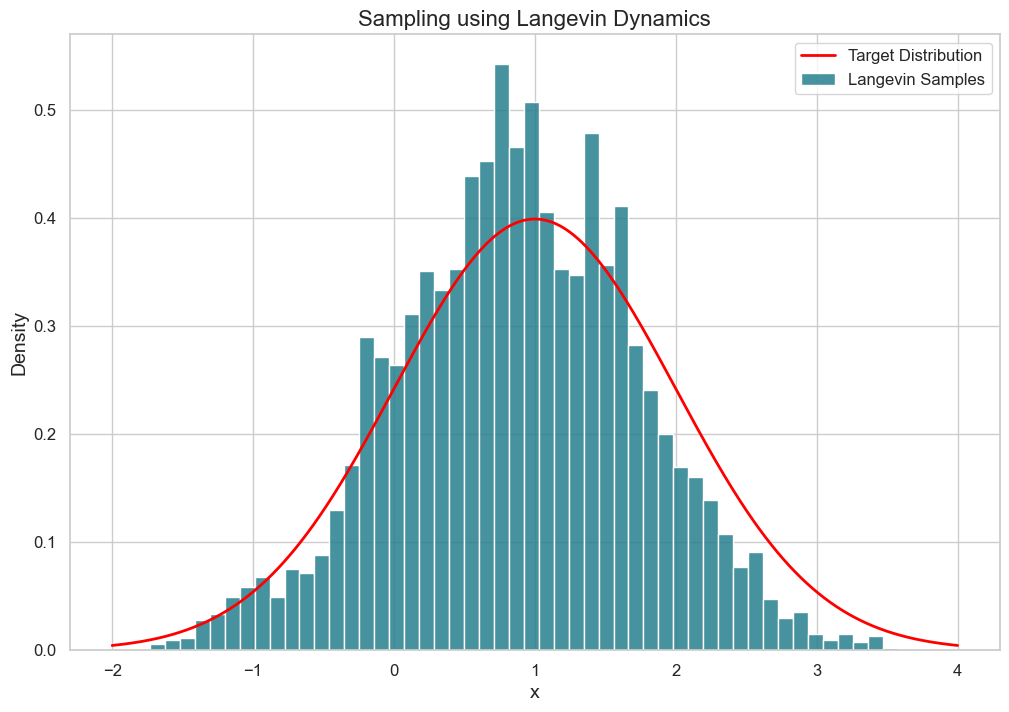

In [10]:
gamma = 0.01
n_steps = 5000

X = 0
samples = []

# Langevin dynamics simulation
for _ in range(n_steps):
    grad_V = X - 1
    noise = np.sqrt(2 * gamma) * np.random.normal()
    X = X - grad_V * gamma + noise
    samples.append(X)

# Plotting the histogram of samples using Seaborn
plt.figure()
sns.histplot(samples, bins=50, kde=False, stat="density", color=sns.color_palette("viridis")[2], alpha=0.85, label="Langevin Samples")

# Overlay true target distribution for comparison
x = np.linspace(-2, 4, 1000)
target_distribution = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * (x - 1)**2)
plt.plot(x, target_distribution, 'r', lw=2, label='Target Distribution')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Sampling using Langevin Dynamics')
plt.legend()
plt.show()

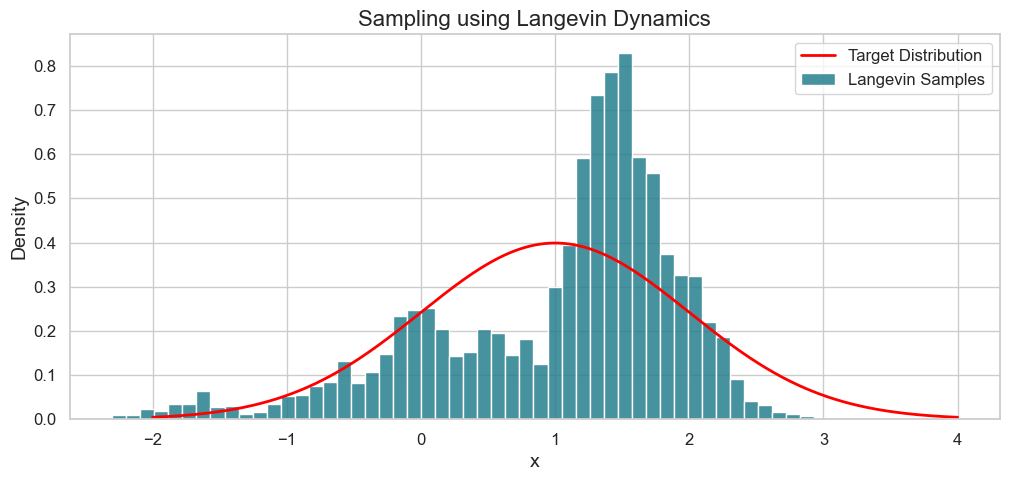

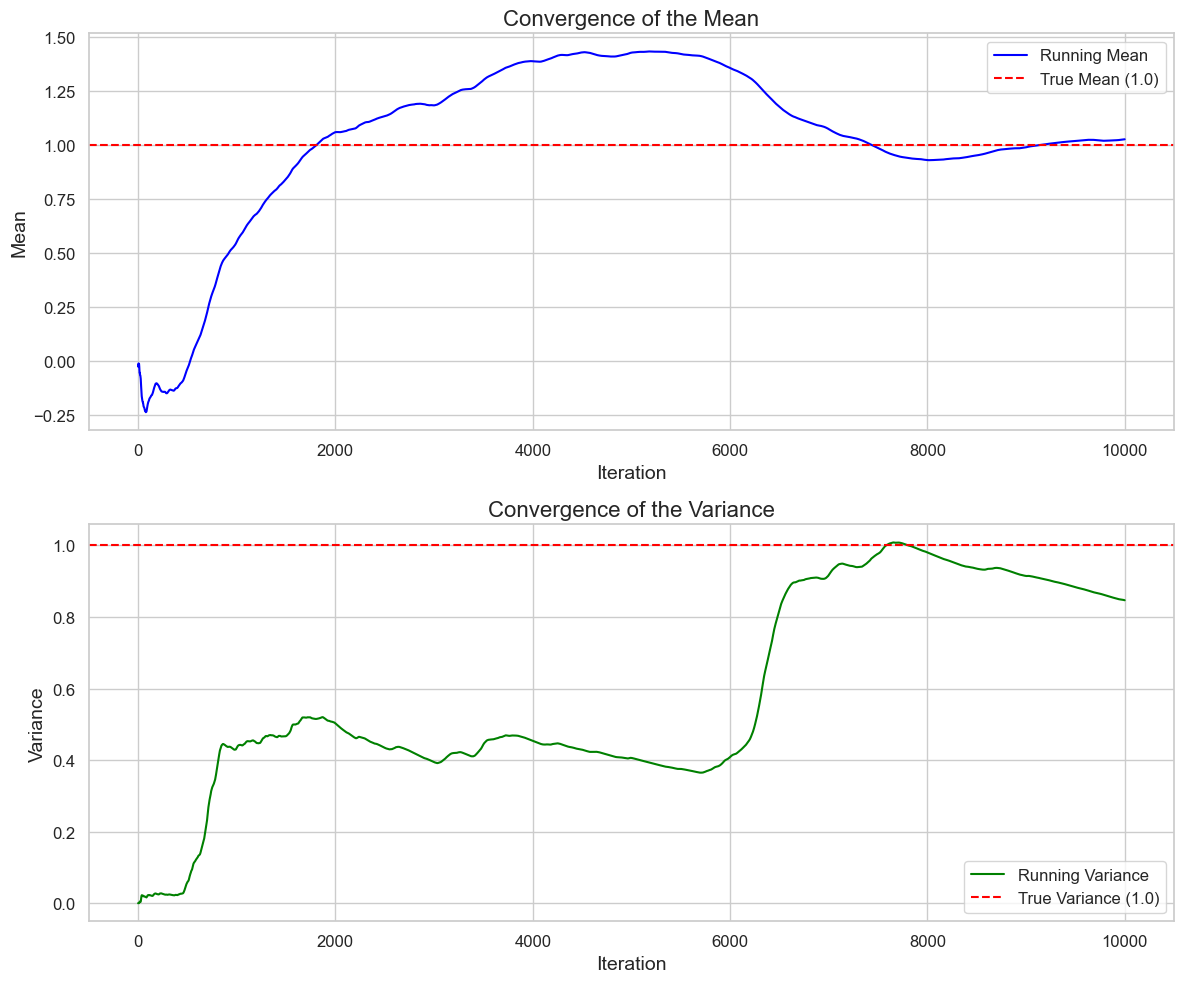

In [17]:
# Parameters
gamma = 0.001
n_steps = 10_000

# Langevin dynamics simulation
X = 0
samples = []
means = []
variances = []

# Langevin dynamics loop
for step in range(1, n_steps + 1):
    grad_V = X - 1
    noise = np.sqrt(2 * gamma) * np.random.normal()

    X = X - grad_V * gamma + noise
    samples.append(X)

    running_mean = np.mean(samples)
    running_variance = np.var(samples)

    means.append(running_mean)
    variances.append(running_variance)

# Plotting the histogram of samples using Seaborn
plt.figure(figsize=(12, 5))
sns.histplot(samples, bins=50, kde=False, stat="density", color=sns.color_palette("viridis")[2], alpha=0.85, label="Langevin Samples")
# plt.plot(samples)

# Overlay true target distribution for comparison
x = np.linspace(-2, 4, 1000)
target_distribution = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * (x - 1)**2)
plt.plot(x, target_distribution, 'r', lw=2, label='Target Distribution')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Sampling using Langevin Dynamics')
plt.legend()
plt.show()

# Plotting convergence of mean and variance
plt.figure(figsize=(12, 10))

# Mean convergence plot
plt.subplot(2, 1, 1)
plt.plot(means, label='Running Mean', color='blue')
plt.axhline(y=1.0, color='r', linestyle='--', label='True Mean (1.0)')
plt.xlabel('Iteration')
plt.ylabel('Mean')
plt.title('Convergence of the Mean')
plt.legend()

# Variance convergence plot
plt.subplot(2, 1, 2)
plt.plot(variances, label='Running Variance', color='green')
plt.axhline(y=1.0, color='r', linestyle='--', label='True Variance (1.0)')
plt.xlabel('Iteration')
plt.ylabel('Variance')
plt.title('Convergence of the Variance')
plt.legend()

plt.tight_layout()
plt.show()


## Case of unknown potential $V$ ?

In this case we do not have a known $V$, but we may have an access to some random sample $\vec{X} = (X_1, \dots, X_n)$.

But for Langevin Algorithm we still need the function $V$ and its gradient.

Referencing Wikipedia [https://en.wikipedia.org/wiki/Kernel_density_estimation] we apply Kernel density estimation.

Then the estimation of the density function $\pi(x)$ would be
$$
\hat{\pi}(x) = \frac{1}{nh} \sum^{n}_{i=1} \mathcal{K} \left(\frac{x - x_i}{h}\right)
$$
where
- $n$ is the number of data points (sample size)
- $h>0$ is the smoothing parameter (called bandwidth)
- $\mathcal{K}$ is the kernel (a non-negative function)

In [5]:
from scipy.stats import gaussian_kde

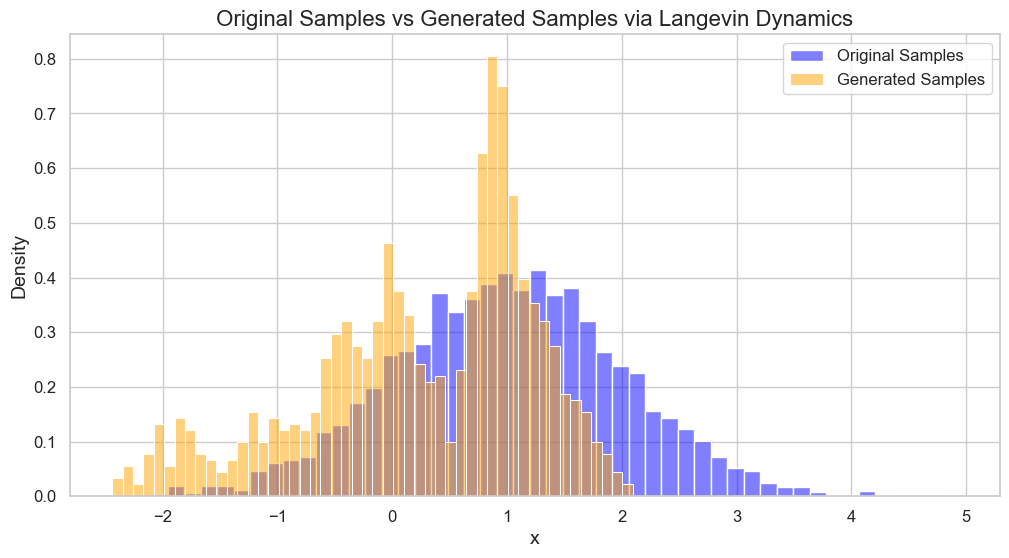

In [6]:
# Given sample data of size 5000 (e.g., sampled from a Gaussian distribution)
np.random.seed(42)
given_samples = np.random.normal(1, 1, 5000)

kde = gaussian_kde(given_samples)

# Define the potential function V(x) based on KDE
def V(x):
    # -log(p(x)), where p(x) is estimated by KDE
    p_x = kde(x)
    return -np.log(p_x)

# Langevin dynamics parameters
gamma = 0.01
beta = 1.0
n_steps = 1000

# Start from an arbitrary value
X = 0.0
generated_samples = []

# Langevin dynamics simulation
for _ in range(n_steps):
    # Numerical gradient approximation of V(x)
    epsilon = 1e-5
    grad_V = (V(np.array([X + epsilon])) - V(np.array([X - epsilon]))) / (2 * epsilon)
    
    noise = np.sqrt(2 * beta**-1 * gamma) * np.random.normal()
    X = X - grad_V * gamma + noise

    generated_samples.append(X[0])

# Plotting the original samples and generated samples
plt.figure(figsize=(12, 6))

# Using Seaborn to plot histograms of original and generated samples
sns.histplot(given_samples, bins=50, kde=False, stat="density", color="blue", alpha=0.5, label="Original Samples")
sns.histplot(generated_samples, bins=50, kde=False, stat="density", color="orange", alpha=0.5, label="Generated Samples")

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Original Samples vs Generated Samples via Langevin Dynamics')
plt.legend()
plt.show()

### An implementation without the usage of `scipy.stats.gaussian_kde`

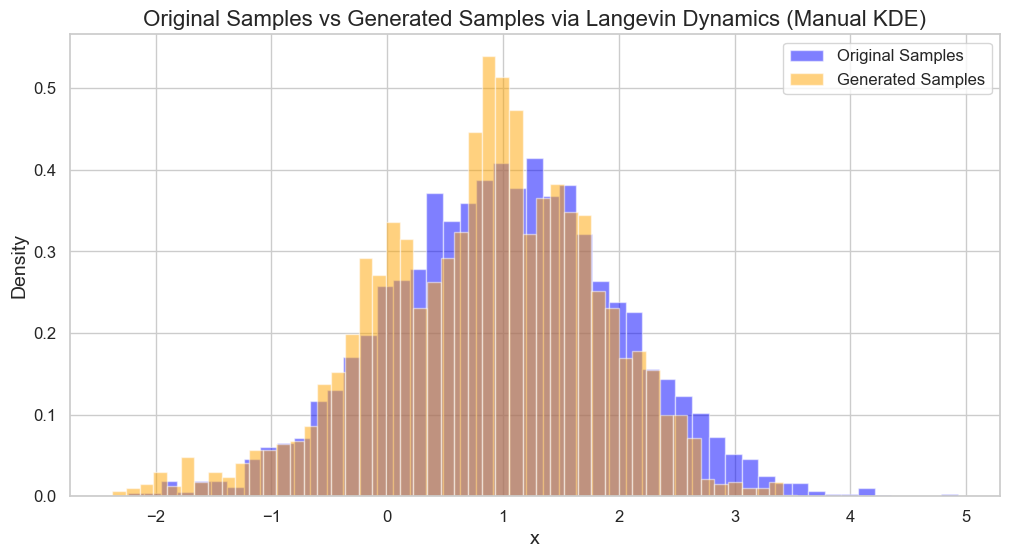

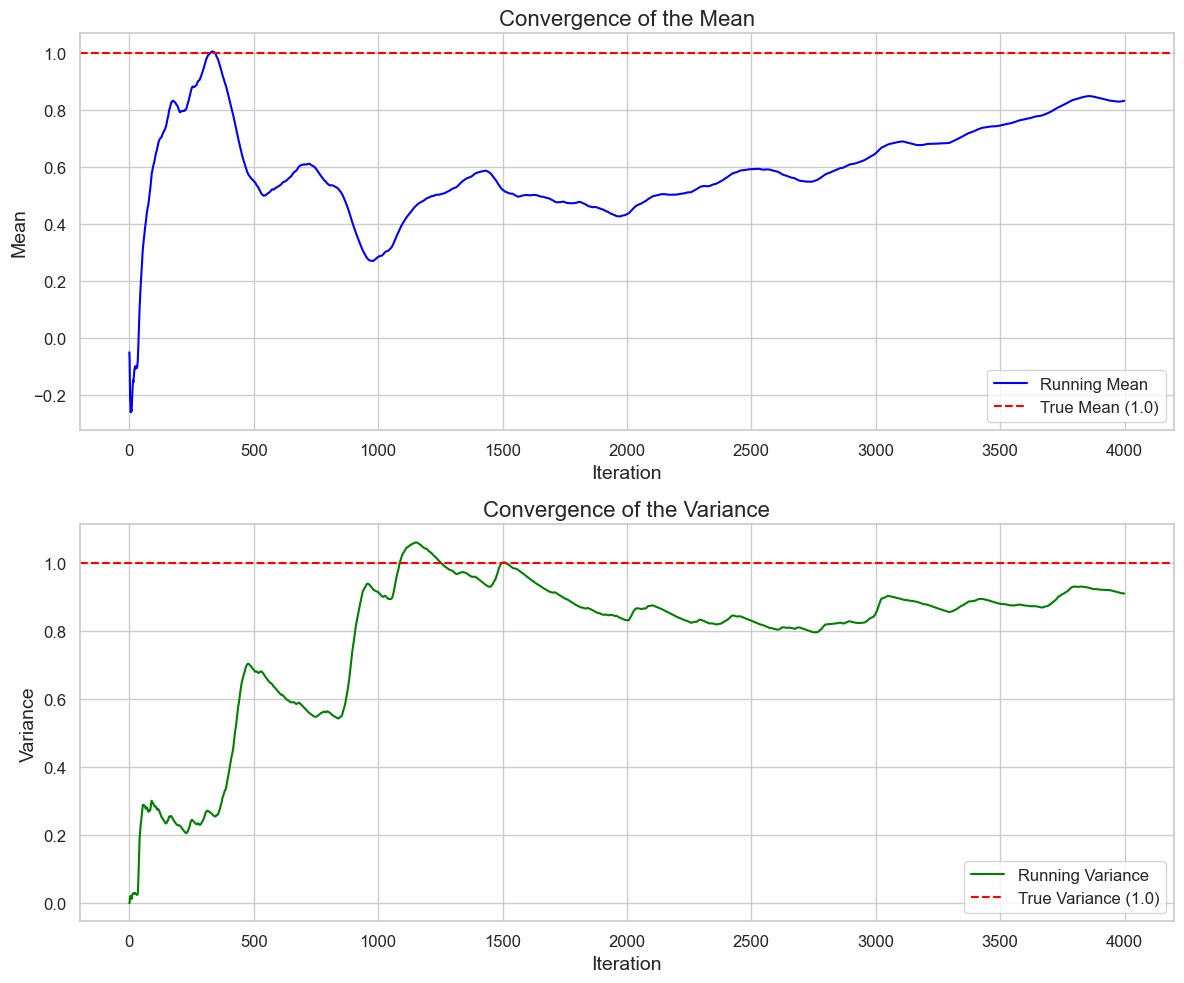

In [19]:
# Given sample data of size 5000 (e.g., sampled from a Gaussian distribution)
np.random.seed(42)
given_samples = np.random.normal(1, 1, 5000)

# Define a simple KDE function using Gaussian kernel
def kde_manual(x, samples, bandwidth=0.1):
    """Estimate the density at point x using manual Gaussian KDE."""
    n = len(samples)
    kernel_values = np.exp(-0.5 * ((x - samples) / bandwidth) ** 2)
    density = np.sum(kernel_values) / (n * bandwidth * np.sqrt(2 * np.pi))
    return density

# Define the potential function V(x) based on manual KDE
def V(x):
    """Potential function based on the estimated density from manual KDE."""
    p_x = kde_manual(x, given_samples)
    return -np.log(p_x + 1e-10)  # Adding a small value to avoid log(0)

# Langevin dynamics parameters
gamma = 0.01
beta = 1.0
n_steps = 4000

X = 0.0
generated_samples = []
means = []
variances = []

# Langevin dynamics simulation
for _ in range(n_steps):
    # Numerical gradient approximation of V(x)
    epsilon = 1e-5
    grad_V = (V(X + epsilon) - V(X - epsilon)) / (2 * epsilon)
    
    noise = np.sqrt(2 * beta**-1 * gamma) * np.random.normal()
    X = X - grad_V * gamma + noise

    generated_samples.append(X)

    running_mean = np.mean(generated_samples)
    running_variance = np.var(generated_samples)
    means.append(running_mean)
    variances.append(running_variance)

# Plotting the original samples and generated samples
plt.figure(figsize=(12, 6))

# Histogram of the original samples
plt.hist(given_samples, bins=50, density=True, alpha=0.5, color='blue', label='Original Samples')

# Histogram of the generated samples
plt.hist(generated_samples, bins=50, density=True, alpha=0.5, color='orange', label='Generated Samples')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Original Samples vs Generated Samples via Langevin Dynamics (Manual KDE)')
plt.legend()
plt.show()

# Plotting convergence of mean and variance
plt.figure(figsize=(12, 10))

# Mean convergence plot
plt.subplot(2, 1, 1)
plt.plot(means, label='Running Mean', color='blue')
plt.axhline(y=1.0, color='r', linestyle='--', label='True Mean (1.0)')
plt.xlabel('Iteration')
plt.ylabel('Mean')
plt.title('Convergence of the Mean')
plt.legend()

# Variance convergence plot
plt.subplot(2, 1, 2)
plt.plot(variances, label='Running Variance', color='green')
plt.axhline(y=1.0, color='r', linestyle='--', label='True Variance (1.0)')
plt.xlabel('Iteration')
plt.ylabel('Variance')
plt.title('Convergence of the Variance')
plt.legend()

plt.tight_layout()
plt.show()